In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)
 
 
# Ajustar path según estructura del proyecto
df = pd.read_csv("../Exploracion/BD_Adult_income/Adult_income_dataset.csv",header=0, na_values='?')
 
# Vista inicial de los datos
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [2]:
# =====================================
# Revisión de valores faltantes
# =====================================
print("Valores faltantes por columna:\n", df.isna().sum())
 
# Estrategia de tratamiento: reemplazo con 'Unknown' en categóricas
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')
print("\nValores faltantes después del tratamiento:\n", df.isna().sum())

Valores faltantes por columna:
 age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

Valores faltantes después del tratamiento:
 age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


C:\Users\Mateo\AppData\Local\Temp\ipykernel_10696\1211754314.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


In [3]:
df.dtypes

age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object

In [4]:
# =====================================
# Estadísticas descriptivas univariadas
# =====================================
# Variables numéricas
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols].describe()
 
# Variables categóricas
df[categorical_cols].describe()

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,48842,48842,48842,48842,48842,48842,48842,48842,48842
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


age: 216 outliers detectados


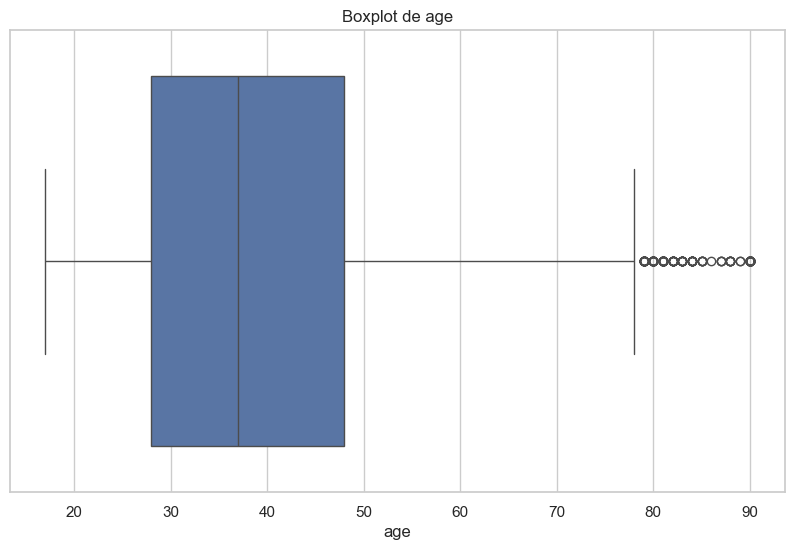

fnlwgt: 1453 outliers detectados


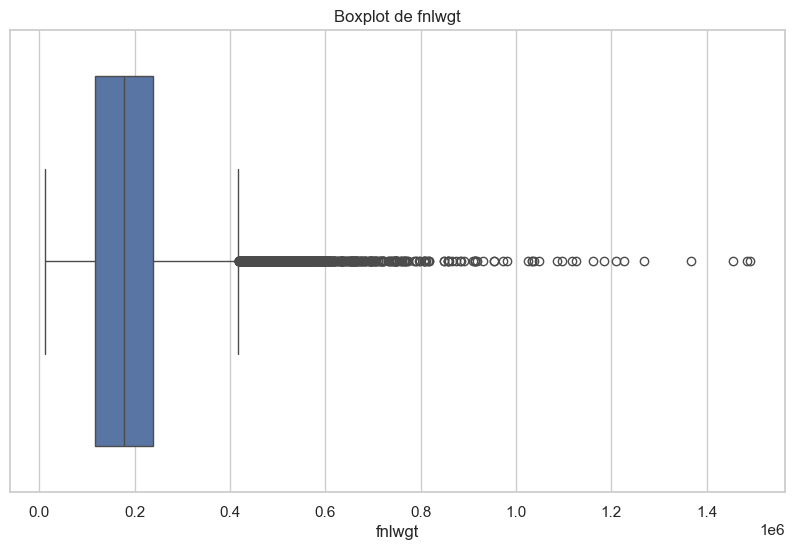

educational-num: 1794 outliers detectados


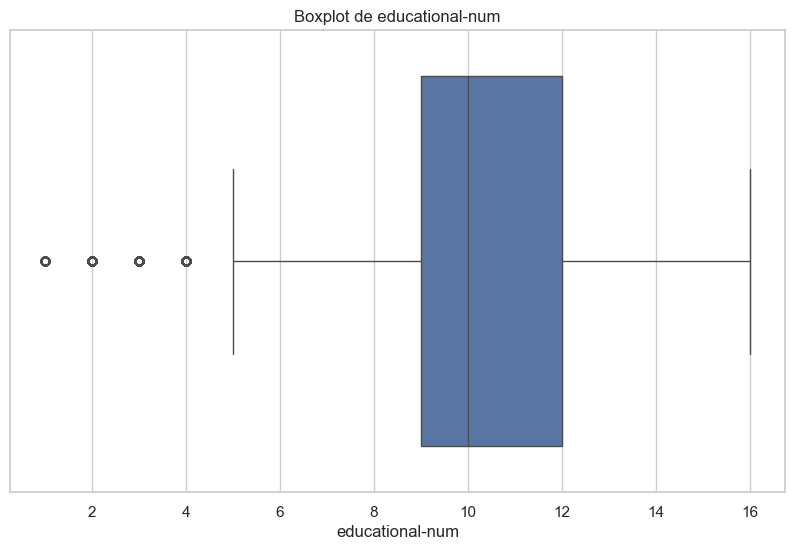

capital-gain: 4035 outliers detectados


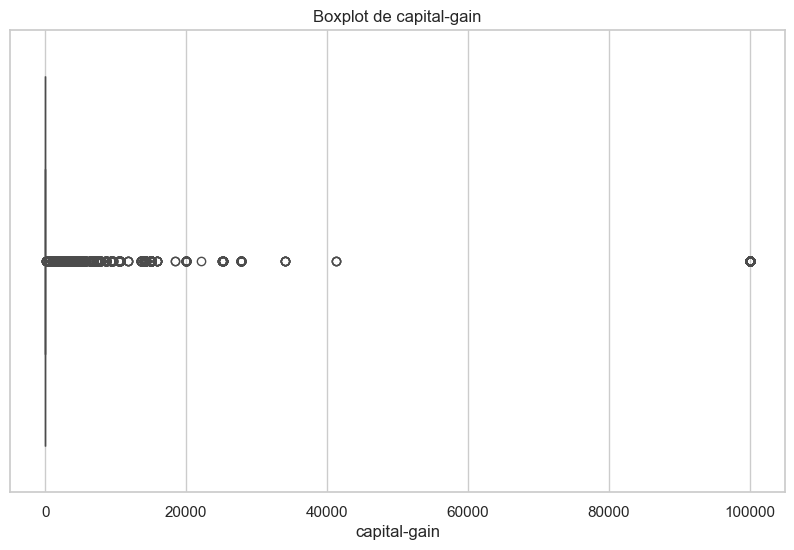

capital-loss: 2282 outliers detectados


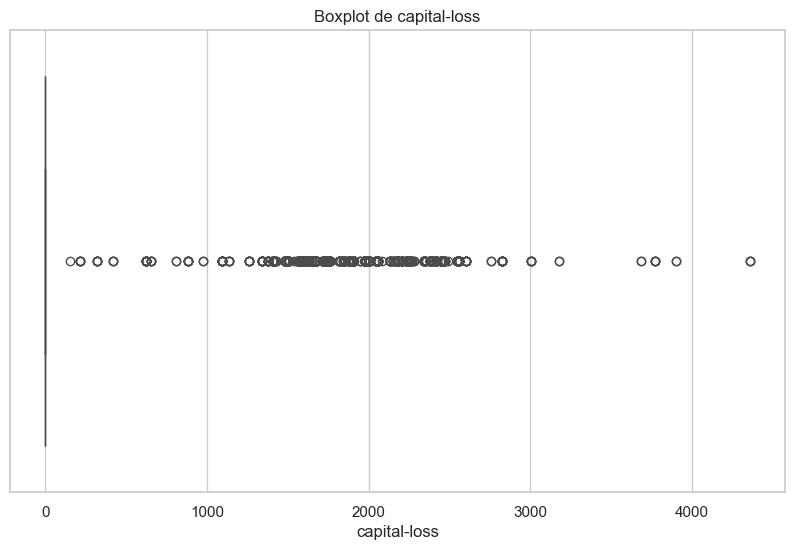

hours-per-week: 13496 outliers detectados


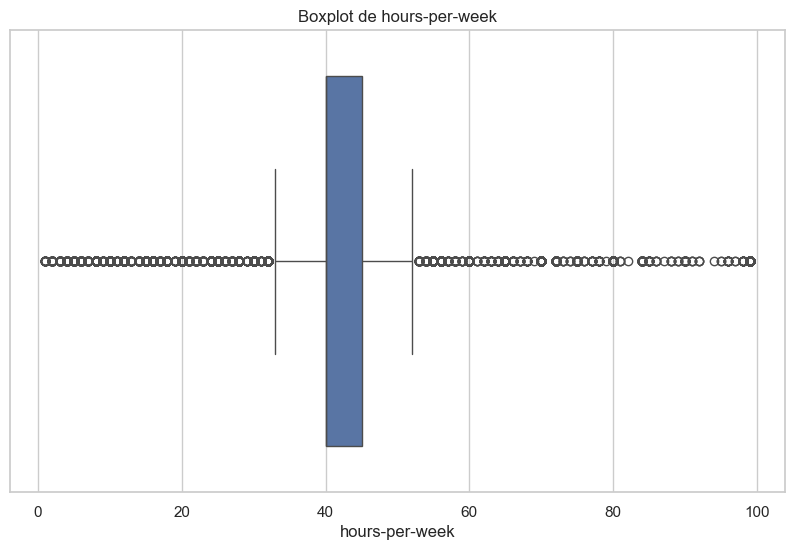

In [5]:
# =====================================
# Detección de outliers (valores atípicos)
# =====================================
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers detectados")
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

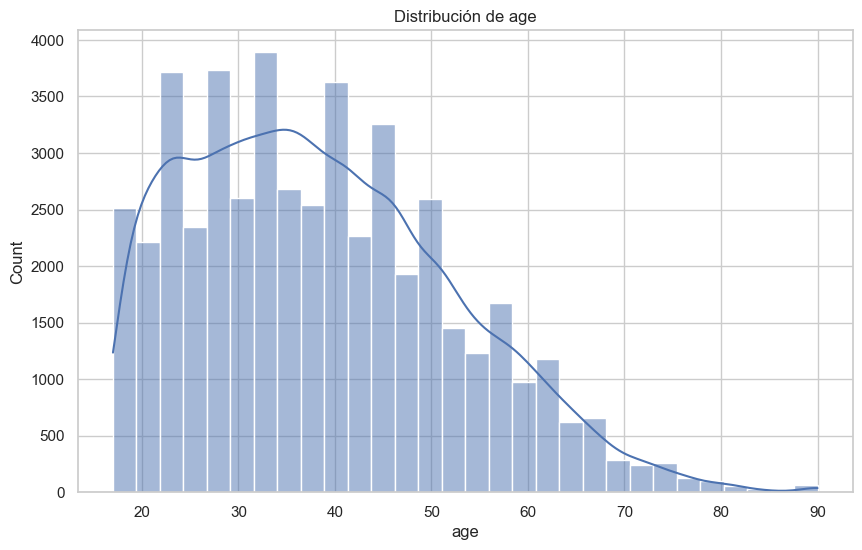

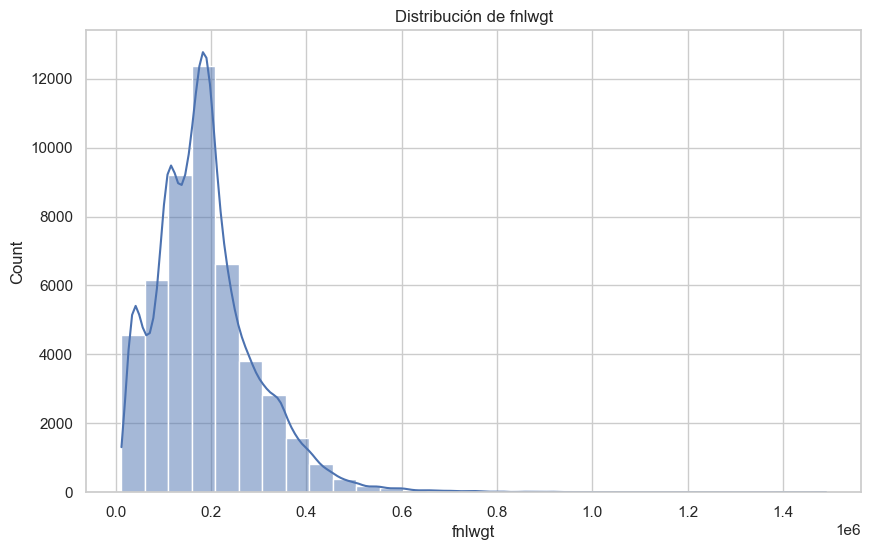

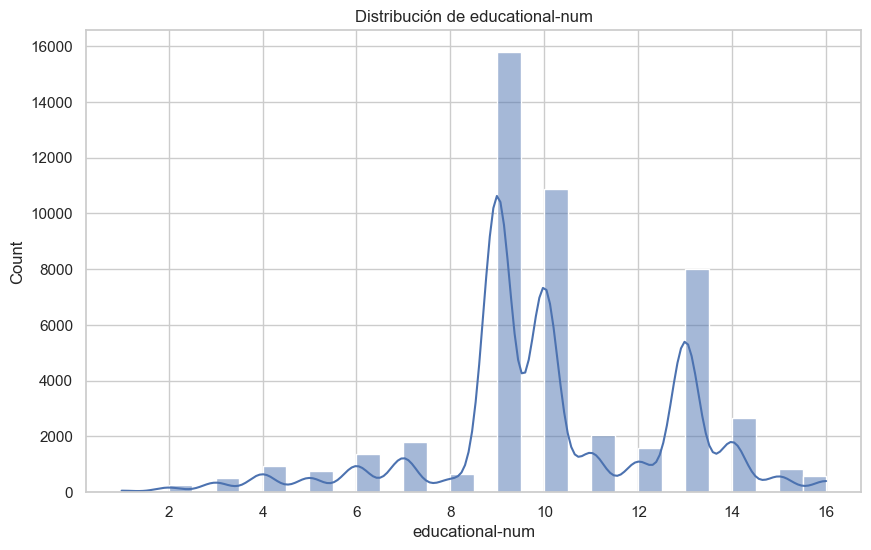

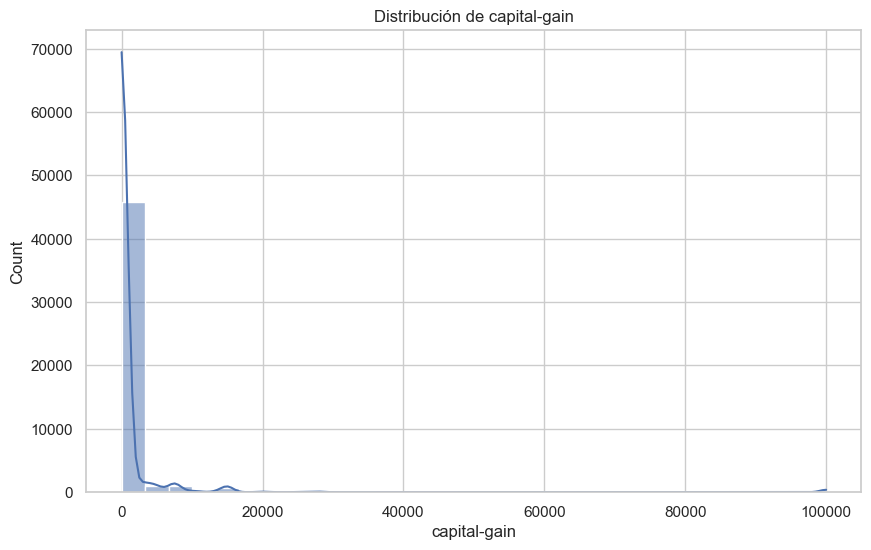

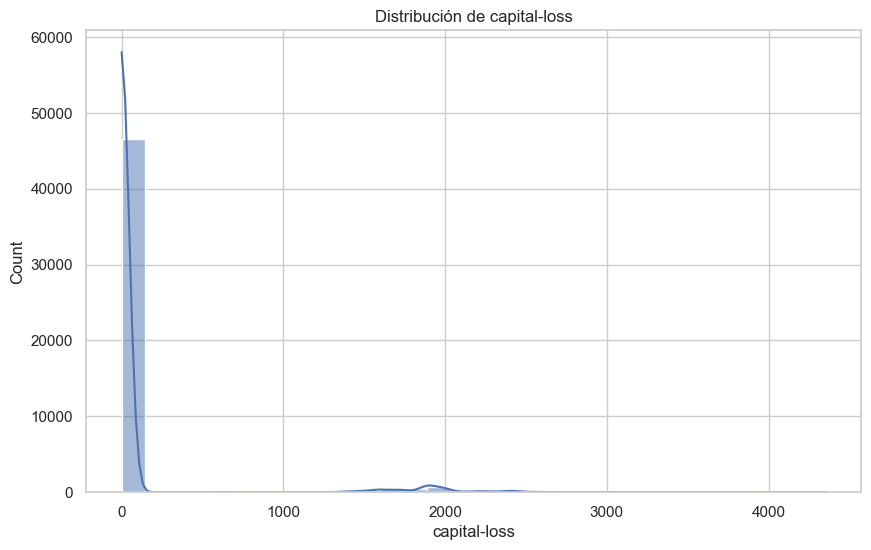

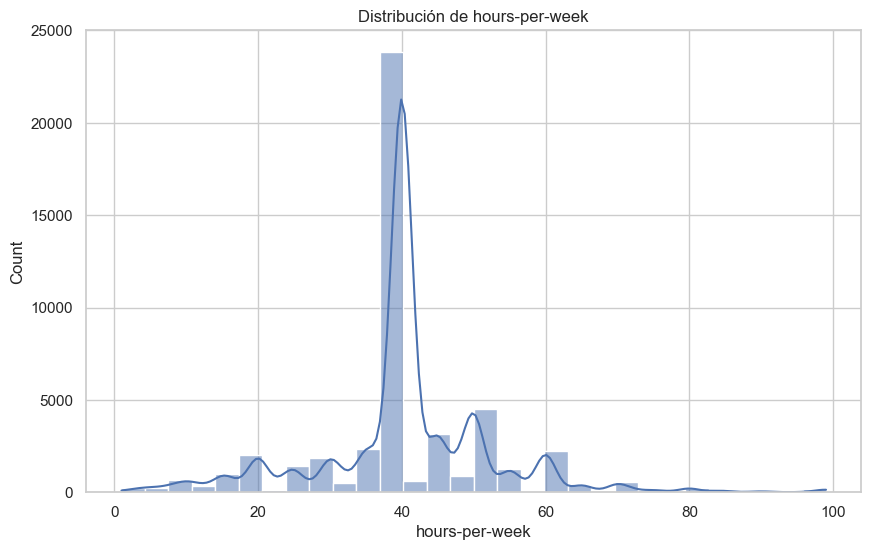

In [6]:
# =====================================
# Análisis de distribuciones
# =====================================
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribución de {col}')
    plt.show()
# Transformación logarítmica para capital-gain y capital-loss
df['capital-gain-log'] = np.log1p(df['capital-gain'])
df['capital-loss-log'] = np.log1p(df['capital-loss'])

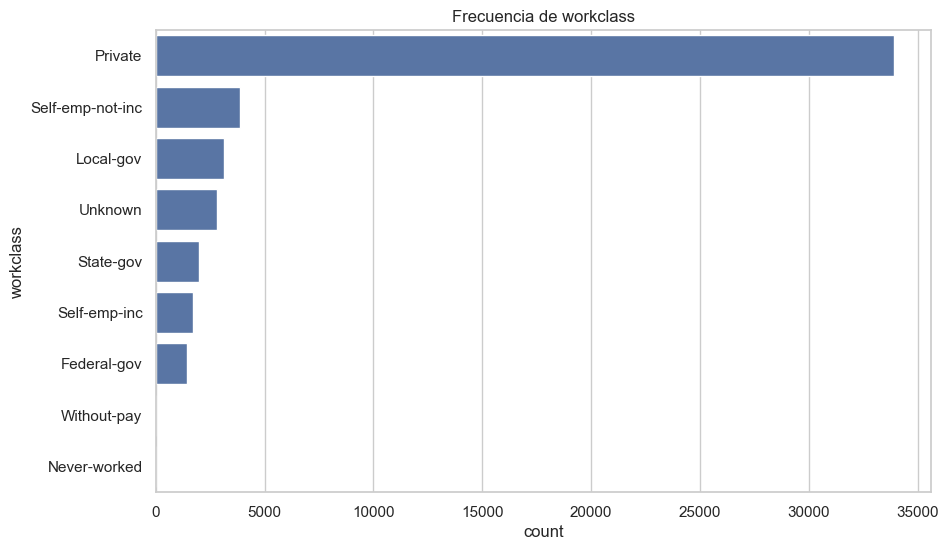

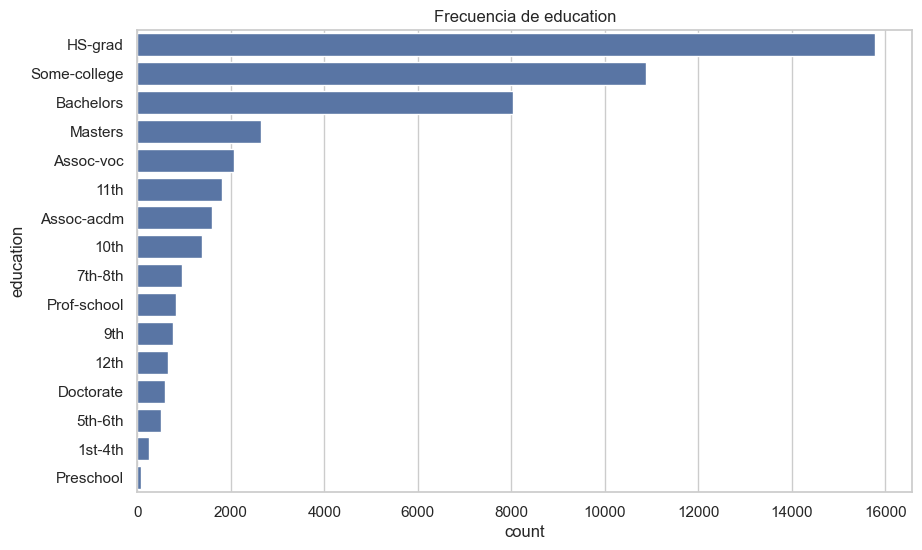

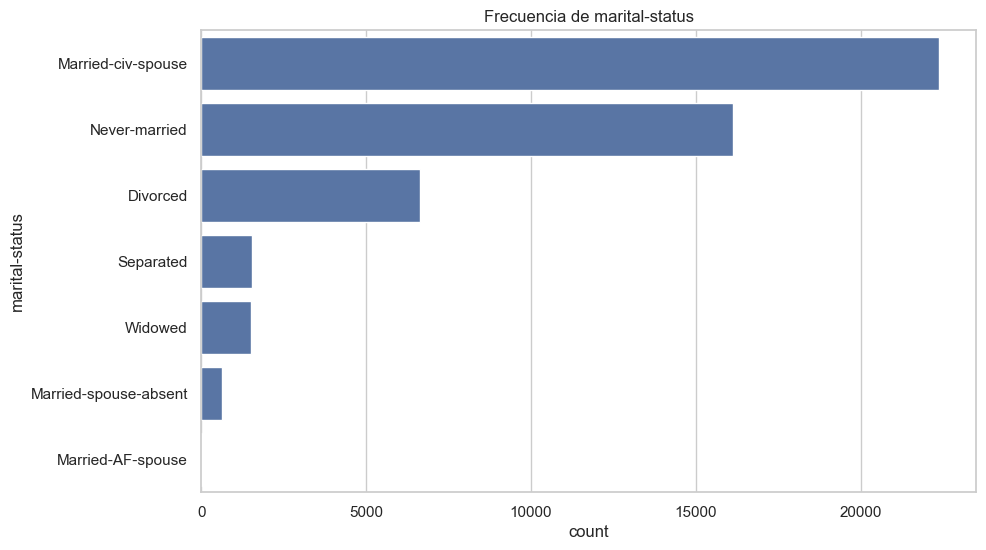

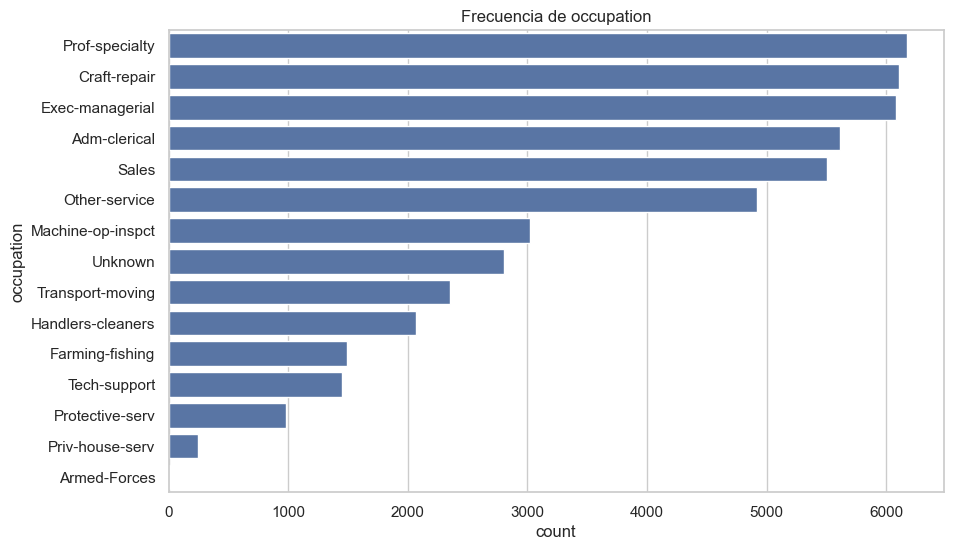

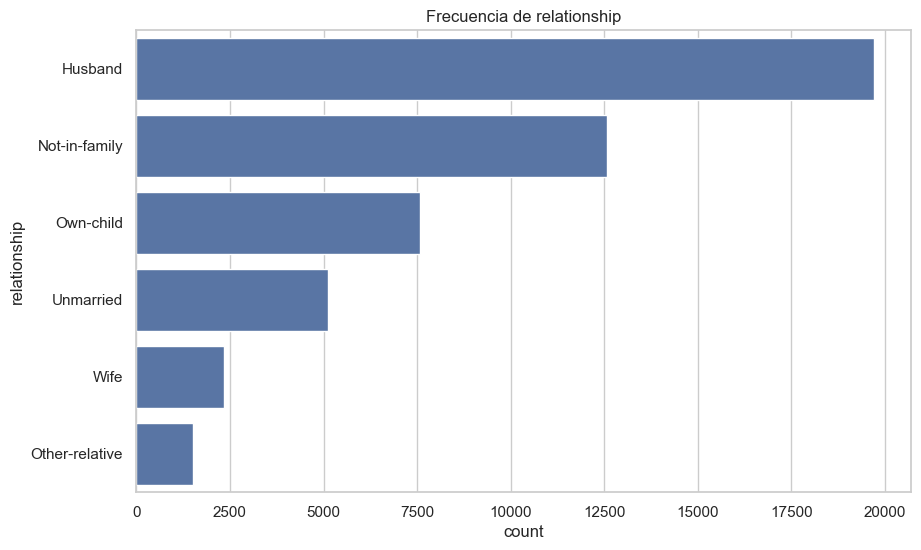

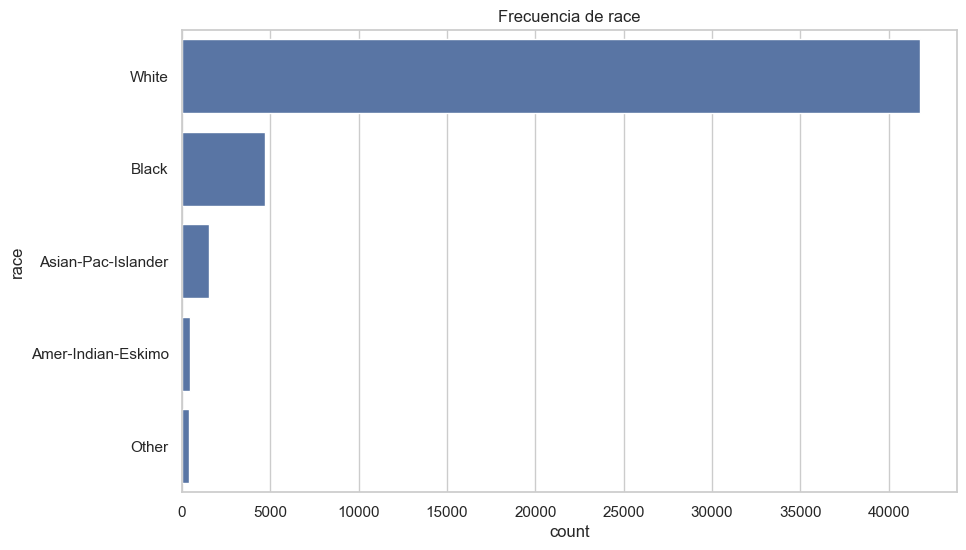

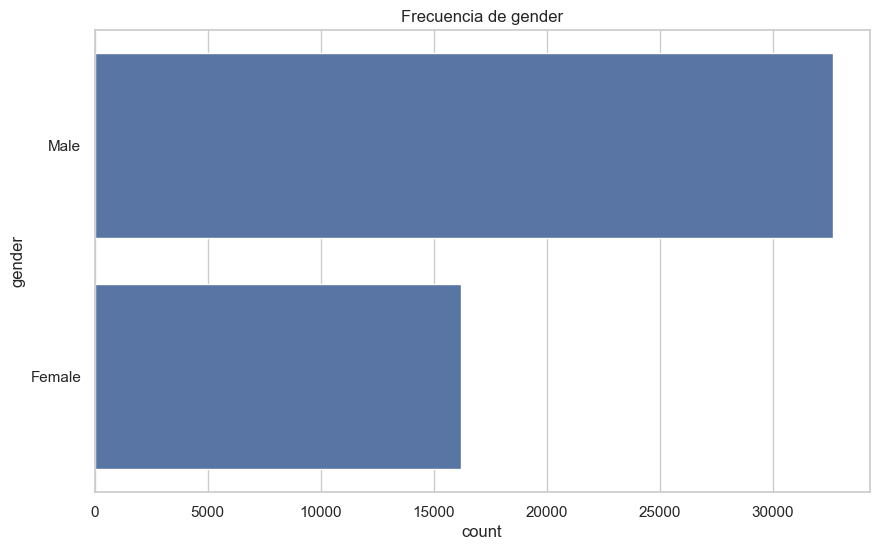

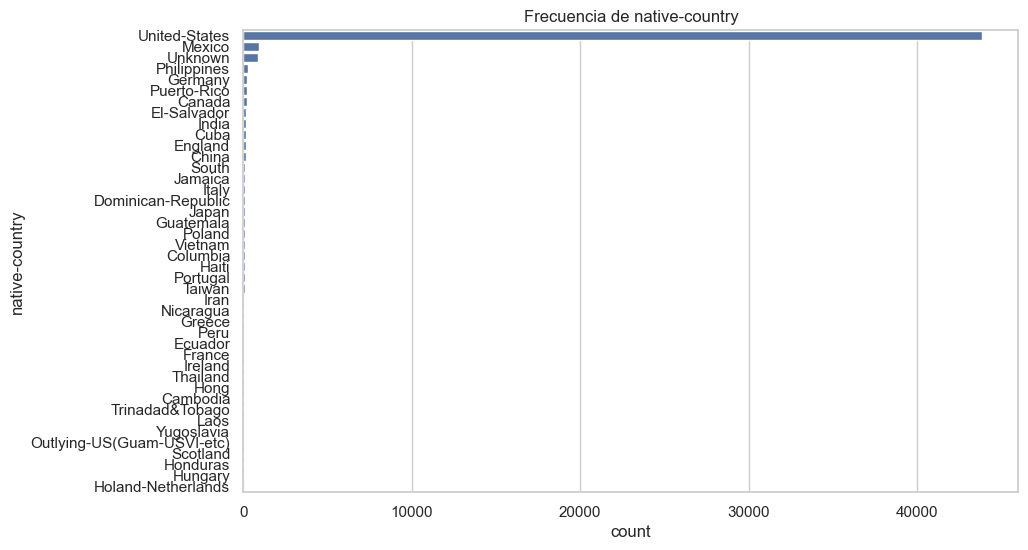

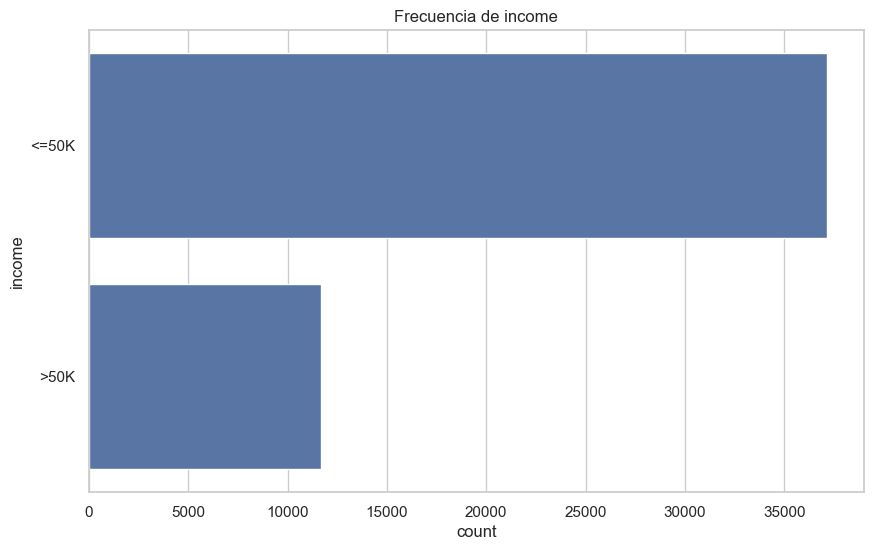

In [7]:
# =====================================
# Análisis univariado categórico
# =====================================
for col in categorical_cols:
    plt.figure()
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Frecuencia de {col}')
    plt.show()

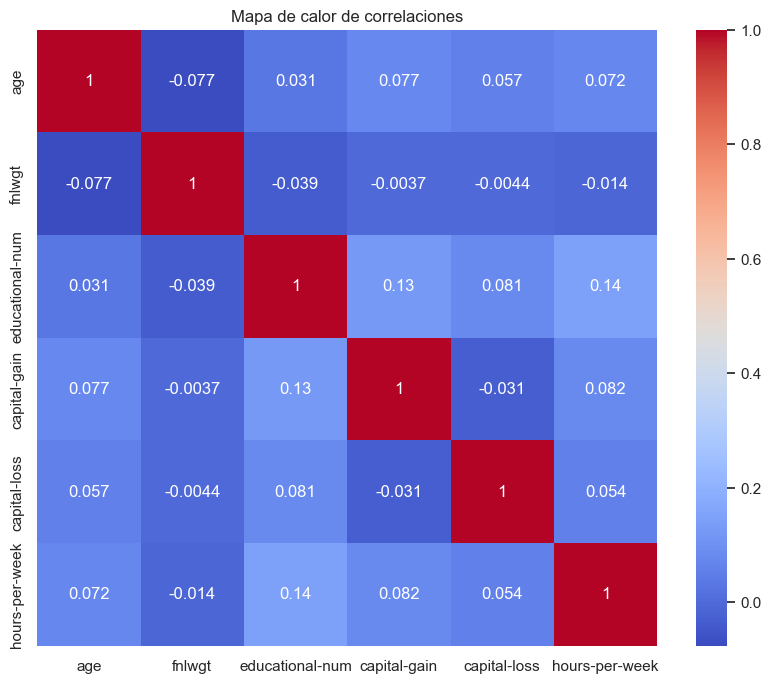

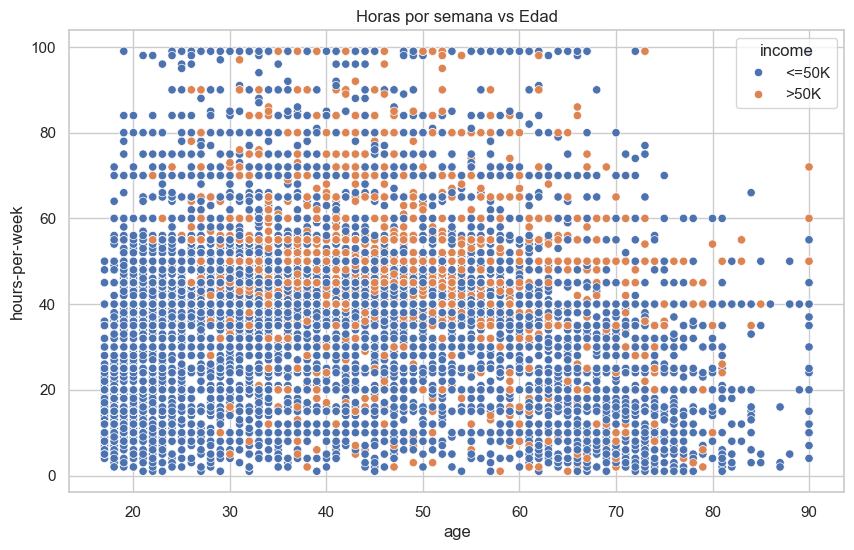

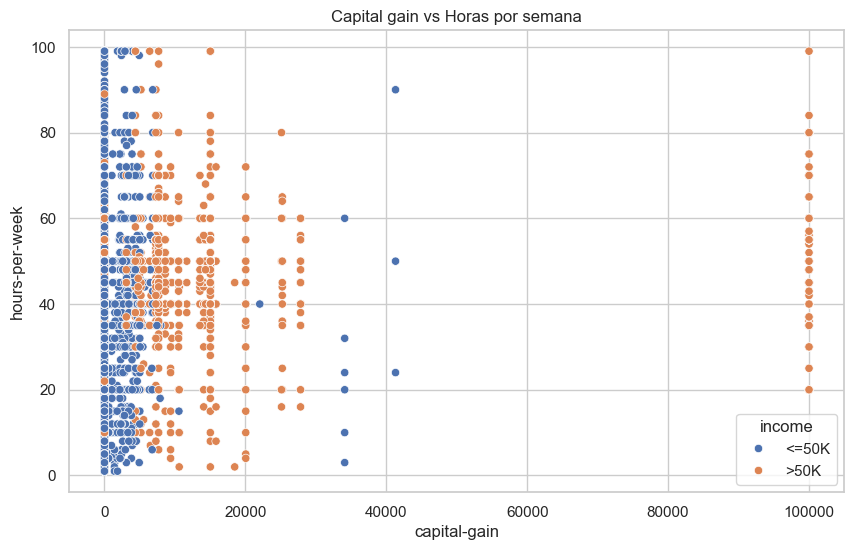

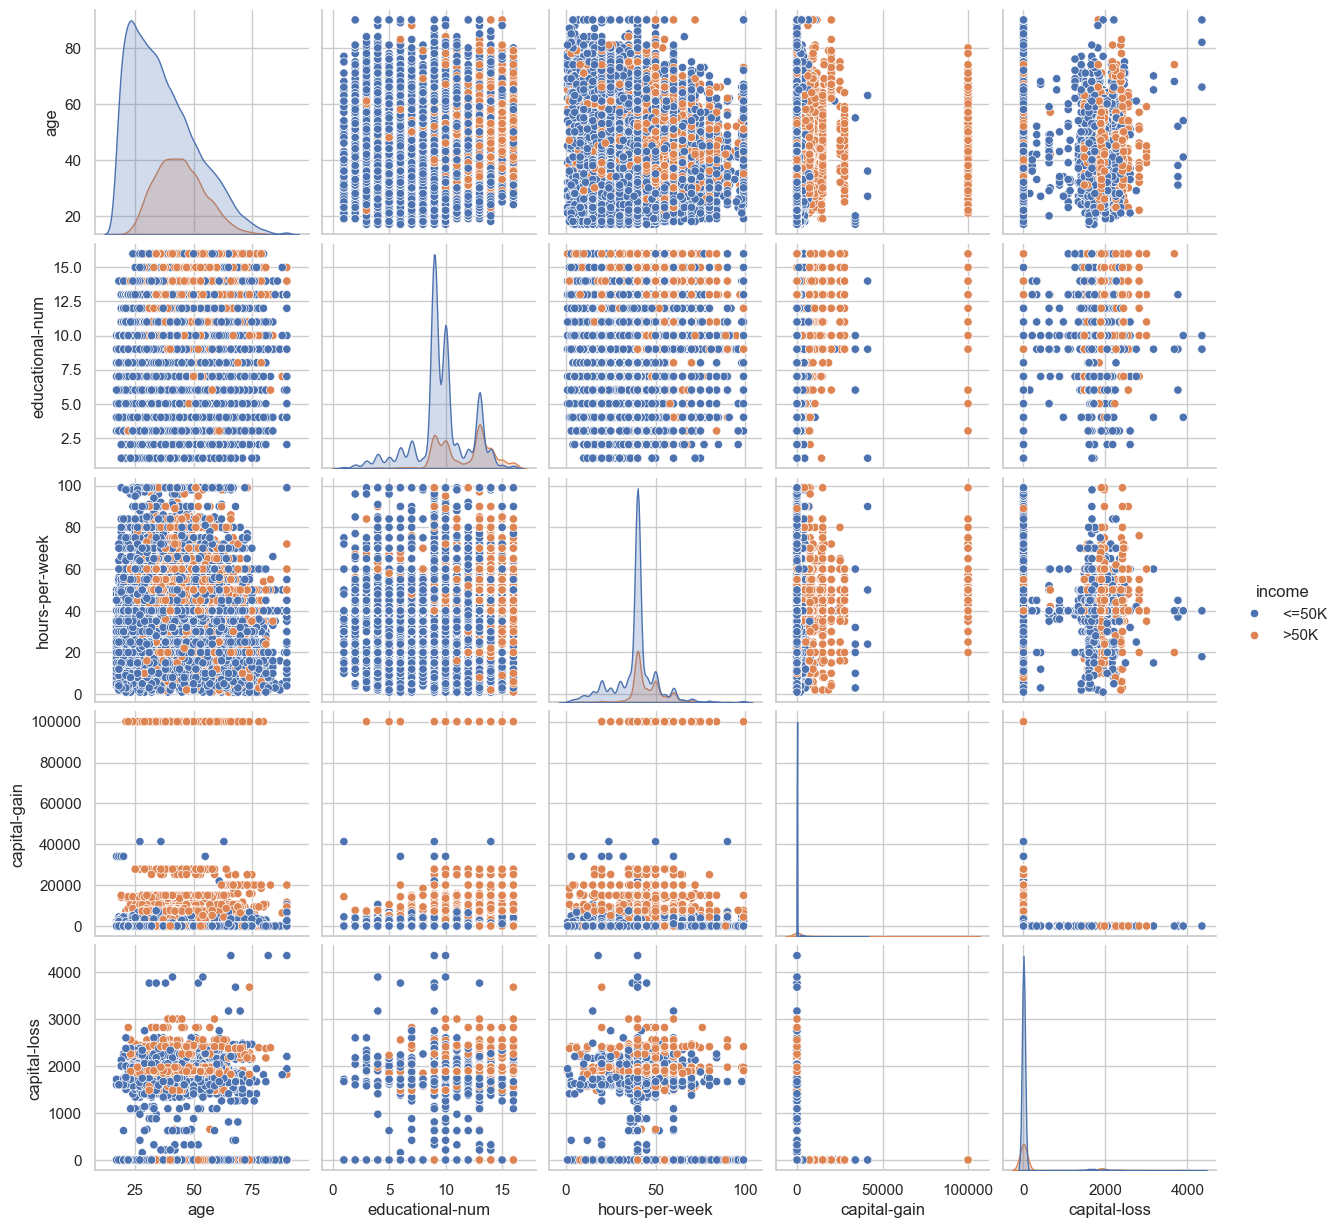

In [8]:
# =====================================
# Análisis multivariado
# =====================================
# Mapa de calor de correlaciones
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Mapa de calor de correlaciones")
plt.show()

# Scatter plots
sns.scatterplot(x='age', y='hours-per-week', hue='income', data=df)
plt.title("Horas por semana vs Edad")
plt.show()

sns.scatterplot(x='capital-gain', y='hours-per-week', hue='income', data=df)
plt.title("Capital gain vs Horas por semana")
plt.show()

# Pairplot variables seleccionadas
sns.pairplot(df[['age','educational-num','hours-per-week','capital-gain','capital-loss','income']], hue='income')
plt.show()

In [9]:
# =====================================
# Tablas cruzadas y relaciones categórico-categórico
# =====================================
income_edu = pd.crosstab(df['education'], df['income'], normalize='index') * 100
print("Porcentaje de income por educación:\n", income_edu)

Porcentaje de income por educación:
 income            <=50K       >50K
education                         
10th          93.736501   6.263499
11th          94.922737   5.077263
12th          92.694064   7.305936
1st-4th       96.761134   3.238866
5th-6th       94.695481   5.304519
7th-8th       93.507853   6.492147
9th           94.576720   5.423280
Assoc-acdm    74.203623  25.796377
Assoc-voc     74.672489  25.327511
Bachelors     58.716511  41.283489
Doctorate     27.441077  72.558923
HS-grad       84.142169  15.857831
Masters       45.088446  54.911554
Preschool     98.795181   1.204819
Prof-school   26.019185  73.980815
Some-college  81.035117  18.964883


In [10]:
# =====================================
# Codificación de variables categóricas
# =====================================
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Copia del dataset para trabajar
df_pre = df.copy()

# Identificar columnas categóricas
categorical_cols = df_pre.select_dtypes(include='object').columns
print("Columnas categóricas:", categorical_cols)

# One-Hot Encoding (recomendado)
df_encoded = pd.get_dummies(df_pre, columns=categorical_cols, drop_first=True)

print("Dimensión después de encoding:", df_encoded.shape)
df_encoded.head()

Columnas categóricas: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='str')
Dimensión después de encoding: (48842, 103)


C:\Users\Mateo\AppData\Local\Temp\ipykernel_10696\2379509332.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_pre.select_dtypes(include='object').columns


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,capital-gain-log,capital-loss-log,workclass_Local-gov,workclass_Never-worked,...,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Unknown,native-country_Vietnam,native-country_Yugoslavia,income_>50K
0,25,226802,7,0,0,40,0.000000,0.0,False,False,...,False,False,False,False,False,True,False,False,False,False
1,38,89814,9,0,0,50,0.000000,0.0,False,False,...,False,False,False,False,False,True,False,False,False,False
2,28,336951,12,0,0,40,0.000000,0.0,True,False,...,False,False,False,False,False,True,False,False,False,True
3,44,160323,10,7688,0,40,8.947546,0.0,False,False,...,False,False,False,False,False,True,False,False,False,True
4,18,103497,10,0,0,30,0.000000,0.0,False,False,...,False,False,False,False,False,True,False,False,False,False


In [11]:
# =====================================
# Escalado de variables numéricas
# =====================================
from sklearn.preprocessing import StandardScaler

# Identificar columnas numéricas
num_cols = df_pre.select_dtypes(include=['int64','float64']).columns

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

df_encoded.head()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,capital-gain-log,capital-loss-log,workclass_Local-gov,workclass_Never-worked,...,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Unknown,native-country_Vietnam,native-country_Yugoslavia,income_>50K
0,-0.995129,0.351675,-1.197259,-0.144804,-0.217127,-0.034087,-0.297918,-0.221264,False,False,...,False,False,False,False,False,True,False,False,False,False
1,-0.046942,-0.945524,-0.419335,-0.144804,-0.217127,0.772930,-0.297918,-0.221264,False,False,...,False,False,False,False,False,True,False,False,False,False
2,-0.776316,1.394723,0.747550,-0.144804,-0.217127,-0.034087,-0.297918,-0.221264,True,False,...,False,False,False,False,False,True,False,False,False,True
3,0.390683,-0.277844,-0.030373,0.886874,-0.217127,-0.034087,3.360930,-0.221264,False,False,...,False,False,False,False,False,True,False,False,False,True
4,-1.505691,-0.815954,-0.030373,-0.144804,-0.217127,-0.841104,-0.297918,-0.221264,False,False,...,False,False,False,False,False,True,False,False,False,False


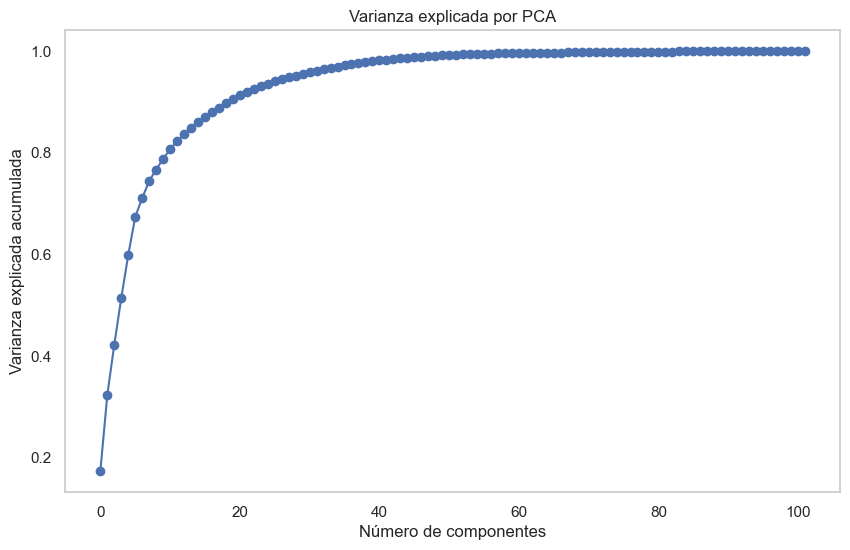

Número óptimo de componentes (>=90% varianza): 20
Nueva dimensión del dataset: (48842, 20)


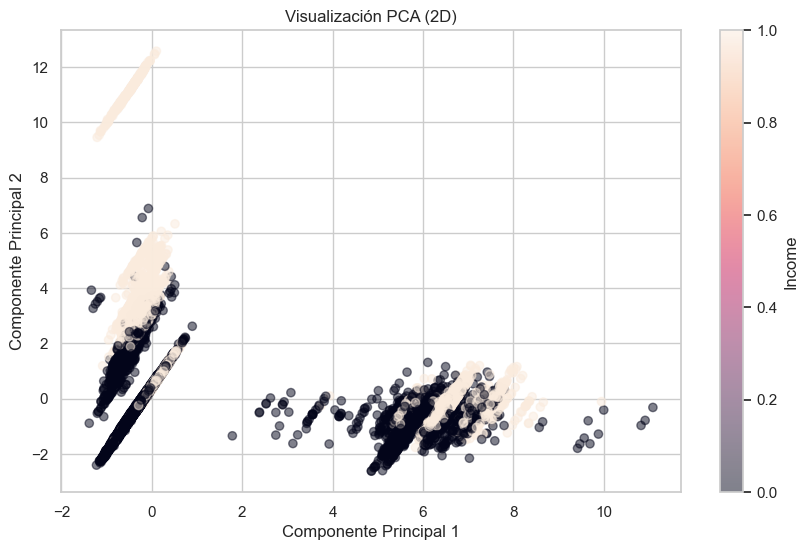

In [12]:
# =====================================
# PCA (Reducción de dimensionalidad)
# =====================================
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Separar variables predictoras (X) y objetivo (y)
# Ajusta el nombre si cambia por el encoding
target_col = [col for col in df_encoded.columns if 'income' in col][0]

X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

# Aplicar PCA completo
pca = PCA()
X_pca = pca.fit_transform(X)

# -------------------------------
# 1. Varianza explicada
# -------------------------------
explained_variance = pca.explained_variance_ratio_

# Gráfica de varianza acumulada
plt.figure()
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada por PCA')
plt.grid()
plt.show()

# -------------------------------
# 2. Selección de componentes
# -------------------------------
# Elegimos componentes que expliquen al menos el 90% de la varianza
n_components = np.argmax(np.cumsum(explained_variance) >= 0.90) + 1
print(f"Número óptimo de componentes (>=90% varianza): {n_components}")

# Aplicar PCA con número óptimo
pca_opt = PCA(n_components=n_components)
X_pca_opt = pca_opt.fit_transform(X)

print("Nueva dimensión del dataset:", X_pca_opt.shape)

# -------------------------------
# 3. Visualización (2 primeras componentes)
# -------------------------------
plt.figure()
plt.scatter(X_pca_opt[:, 0], X_pca_opt[:, 1], c=y, alpha=0.5)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Visualización PCA (2D)')
plt.colorbar(label='Income')
plt.show()